# Red Neuronal para Predicción de Precios de Viviendas
## Caso de Estudio — Firma de Inversión Inmobiliaria

**Objetivo:** Desarrollar un modelo de redes neuronales para predecir precios de viviendas con una precisión superior a métodos tradicionales como la regresión lineal.

**Dataset:** [Housing Prices Dataset — Kaggle](https://www.kaggle.com/datasets/yasserh/housing-prices-dataset)

**Métricas de éxito:**
- RMSE < 15% del precio promedio
- R² > 0.60

---

### Estructura del notebook
1. Configuración e imports
2. Data Processing (carga, exploración, correlación, preprocesamiento)
3. Model Planning (arquitectura y decisiones de diseño)
4. Model Building and Selection (entrenamiento, hiperparámetros, evaluación)
5. Presentación de Resultados
6. Comparación con Baseline (Regresión Lineal)
7. Deployment — Serialización del modelo y API Flask
8. Conclusiones

---
## 1. Configuración e Imports

In [ ]:
# Instalación de dependencias (ejecutar solo si no están instaladas)
%pip install kagglehub tensorflow scikit-learn pandas numpy matplotlib seaborn flask

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow import keras

# Semillas para reproducibilidad
np.random.seed(42)
tf.random.set_seed(42)

pd.set_option('display.max_rows', None)

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")
print("✅ Imports completados")

TensorFlow version: 2.21.0
Keras version: 3.14.1
✅ Imports completados


---
## 2. Data Processing

### 2.1 Carga y Exploración Inicial

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# Descarga automática desde Kaggle
# Requiere cuenta Kaggle y kaggle.json en ~/.kaggle/
# ─────────────────────────────────────────────────────────────────────────────
import kagglehub
path = kagglehub.dataset_download("yasserh/housing-prices-dataset")
df = pd.read_csv(f"{path}/Housing.csv")
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


**Observaciones sobre la carga del dataset:**

El dataset contiene **545 viviendas** con **13 variables**: 5 numéricas (`price`, `area`, `bedrooms`, `bathrooms`, `stories`, `parking`) y 7 categóricas (`mainroad`, `guestroom`, `basement`, `hotwaterheating`, `airconditioning`, `prefarea`, `furnishingstatus`). Las primeras filas muestran viviendas de precio elevado (>11M INR) con características premium: calle principal, aire acondicionado y zona preferencial.

In [3]:
# Tipos de datos y valores nulos
print("Tipos de datos:")
print(df.dtypes)
print(f"\nValores nulos por columna:")
print(df.isnull().sum())
print(f"\nTotal valores nulos: {df.isnull().sum().sum()}")

Tipos de datos:
price               int64
area                int64
bedrooms            int64
bathrooms           int64
stories             int64
mainroad              str
guestroom             str
basement              str
hotwaterheating       str
airconditioning       str
parking             int64
prefarea              str
furnishingstatus      str
dtype: object

Valores nulos por columna:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

Total valores nulos: 0


**Sin valores nulos.** El dataset está limpio: ninguna columna tiene datos faltantes, por lo que no será necesario aplicar ninguna estrategia de imputación. Los tipos de datos son correctos — las variables numéricas ya son `int64` y las categóricas son strings que procesaremos en la fase de preprocesamiento.

In [4]:
# Estadísticas descriptivas
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


**Estadísticas descriptivas clave:**

- **Precio:** media de 4.77M INR con una desviación estándar de 1.87M — hay bastante variabilidad. El rango va de 1.75M a 13.3M, lo que indica la presencia de propiedades de lujo que actúan como outliers superiores.
- **Área:** media de 5.150 pies², con un máximo de 16.200 — casi el triple de la media, lo que sugiere algunos inmuebles muy grandes.
- **Habitaciones:** la mayoría de las viviendas tienen 2-3 habitaciones (mediana=3).
- **Baños:** la gran mayoría tiene solo 1 baño (mediana=1), con muy pocos casos de 3 o 4.
- **Parking:** el 75% de las viviendas tiene 1 o ninguna plaza de aparcamiento.

La diferencia entre la media (4.77M) y la mediana (4.34M) del precio confirma que la distribución está sesgada hacia la derecha — hay más propiedades baratas que caras, pero las caras elevan la media.

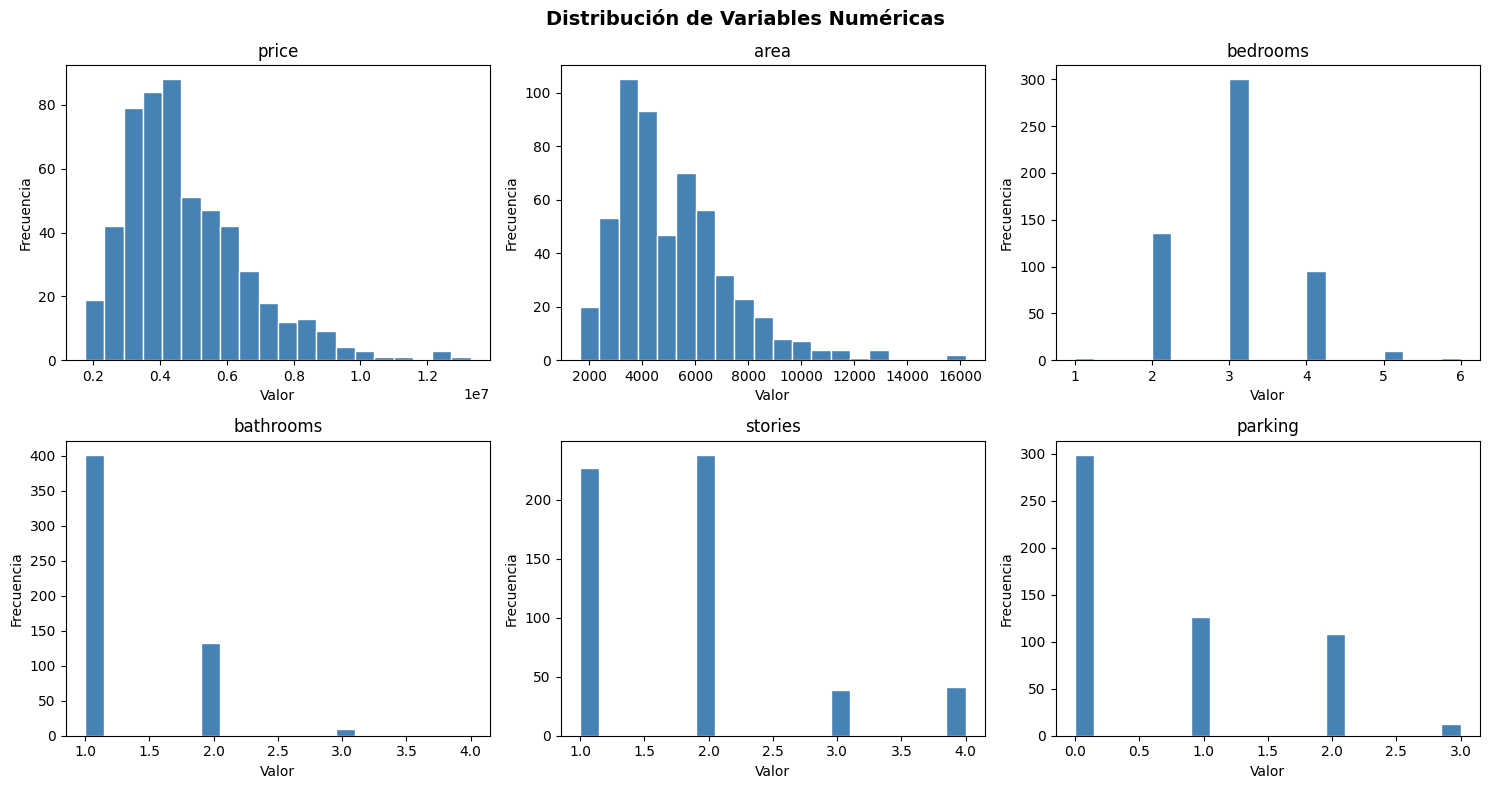


Observaciones:
  - Price: media=4.77M, mediana=4.34M
  - Area: rango [1650 - 16200] pies²
  - El precio tiene cola derecha (distribución sesgada)


In [5]:
# Distribuciones — histogramas de variables numéricas
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

num_cols = ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']
for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=20, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia')

plt.suptitle('Distribución de Variables Numéricas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nObservaciones:")
print(f"  - Price: media={df['price'].mean()/1e6:.2f}M, mediana={df['price'].median()/1e6:.2f}M")
print(f"  - Area: rango [{df['area'].min()} - {df['area'].max()}] pies²")
print(f"  - El precio tiene cola derecha (distribución sesgada)")

**Análisis de los histogramas:**

- **Price:** distribución claramente sesgada a la derecha. La mayoría de viviendas se concentra entre 2M y 7M INR, pero hay un pequeño grupo de propiedades de lujo que llegan hasta 13.3M.
- **Area:** también sesgada a la derecha — la mayoría de viviendas son relativamente pequeñas, con pocos inmuebles de gran superficie.
- **Bedrooms y bathrooms:** distribuciones discretas muy concentradas. La mayoría tiene 2-3 habitaciones y 1 baño.
- **Stories:** la mayoría de propiedades son de 1 o 2 pisos.
- **Parking:** más del 50% de las propiedades no tiene aparcamiento (valor 0).

El sesgo en `price` y `area` es relevante porque puede afectar al entrenamiento del modelo — los valores extremos pueden tener un peso desproporcionado en el cálculo del error.

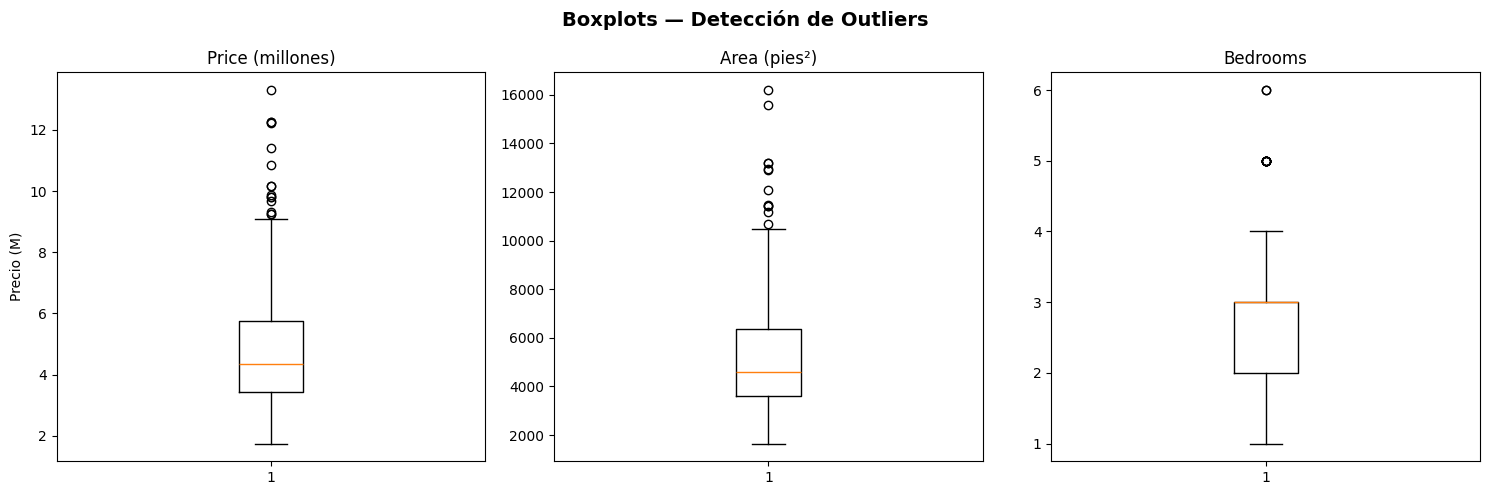

In [6]:
# Boxplots para detectar outliers
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].boxplot(df['price'] / 1e6)
axes[0].set_title('Price (millones)')
axes[0].set_ylabel('Precio (M)')

axes[1].boxplot(df['area'])
axes[1].set_title('Area (pies²)')

axes[2].boxplot(df['bedrooms'])
axes[2].set_title('Bedrooms')

plt.suptitle('Boxplots — Detección de Outliers', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Detección de outliers mediante boxplots:**

Los boxplots confirman la presencia de valores atípicos en las tres variables analizadas:

- **Price:** varios outliers superiores por encima de ~9M INR, correspondientes a propiedades de lujo.
- **Area:** algunos inmuebles con superficie muy por encima de la mediana (~4.600 pies²), llegando hasta 16.200.
- **Bedrooms:** algún caso con 5-6 habitaciones que se aleja claramente de la mayoría.

Estos outliers no se eliminarán porque representan casos reales del mercado inmobiliario que el modelo debería ser capaz de manejar. Sin embargo, serán una fuente importante de error en las predicciones finales.

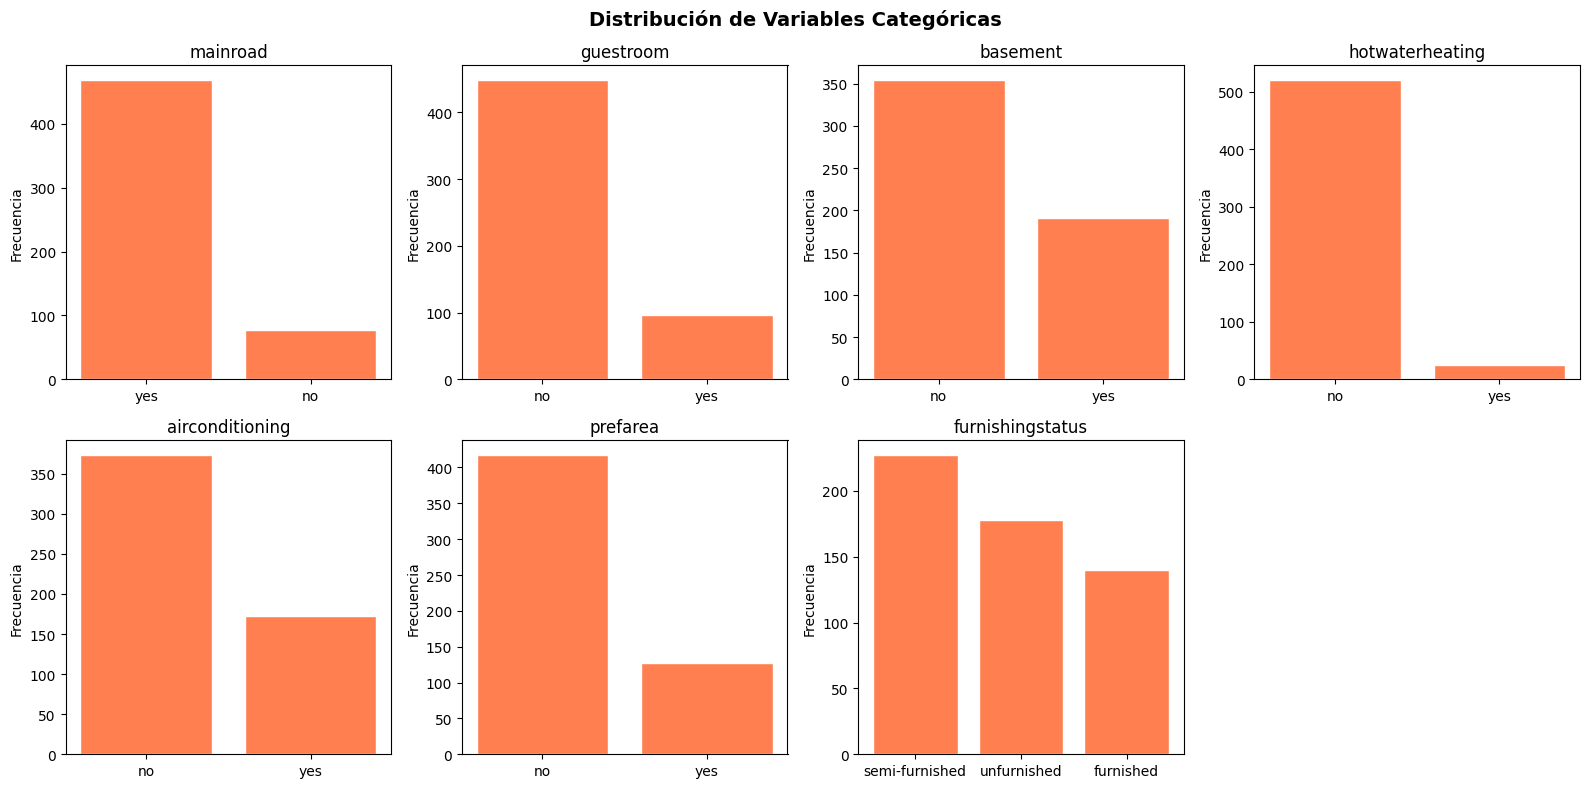

In [7]:
# Distribución de variables categóricas
cat_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating',
            'airconditioning', 'prefarea', 'furnishingstatus']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    axes[i].bar(counts.index, counts.values, color='coral', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_ylabel('Frecuencia')

axes[-1].axis('off')
plt.suptitle('Distribución de Variables Categóricas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Distribución de variables categóricas:**

- **mainroad:** la gran mayoría de viviendas están en calle principal — es una variable con poca varianza, lo que puede limitar su poder predictivo.
- **guestroom y basement:** minoría de viviendas las tienen — serán señales importantes cuando aparecen.
- **hotwaterheating:** muy pocas viviendas lo tienen — variable casi constante, con poco impacto esperado.
- **airconditioning:** presente en aproximadamente la mitad de las viviendas — buena distribución para predecir.
- **prefarea:** alrededor de un tercio de las propiedades están en zona preferencial.
- **furnishingstatus:** distribución bastante equilibrada entre los tres estados (amueblado, semi-amueblado, sin amueblar).

### 2.2 Análisis de Correlación

Para calcular la matriz de correlación necesitamos primero codificar las variables categóricas.

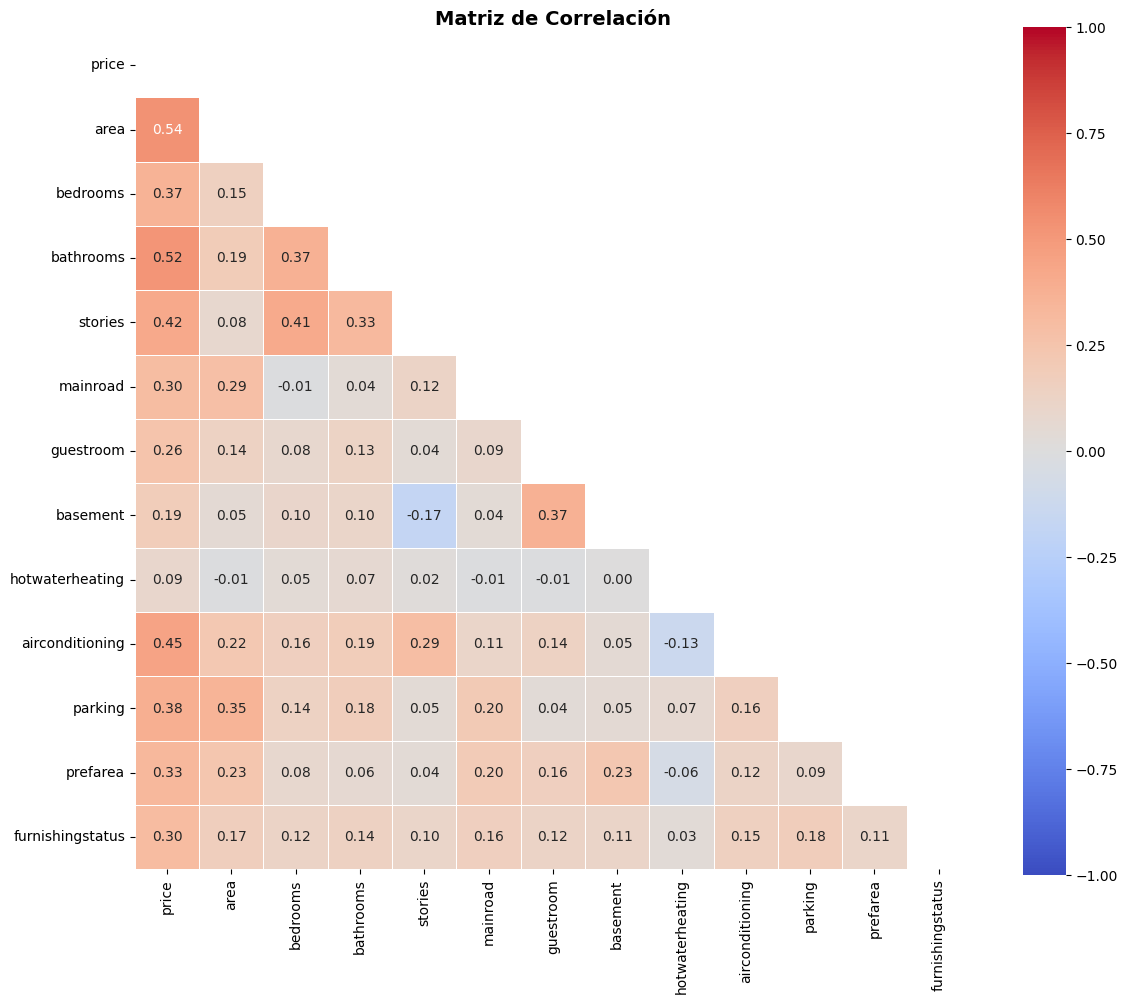


Correlaciones con price (ordenadas):
  area                 +0.536  ██████████
  bathrooms            +0.518  ██████████
  airconditioning      +0.453  █████████
  stories              +0.421  ████████
  parking              +0.384  ███████
  bedrooms             +0.366  ███████
  prefarea             +0.330  ██████
  furnishingstatus     +0.305  ██████
  mainroad             +0.297  █████
  guestroom            +0.256  █████
  basement             +0.187  ███
  hotwaterheating      +0.093  █


In [8]:
# Codificación temporal solo para la correlación
df_corr = df.copy()
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating',
               'airconditioning', 'prefarea']
for col in binary_cols:
    df_corr[col] = df_corr[col].map({'yes': 1, 'no': 0})

furnishing_map = {'furnished': 2, 'semi-furnished': 1, 'unfurnished': 0}
df_corr['furnishingstatus'] = df_corr['furnishingstatus'].map(furnishing_map)

# Matriz de correlación
plt.figure(figsize=(12, 10))
corr_matrix = df_corr.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, vmin=-1, vmax=1, center=0,
            square=True, linewidths=0.5)
plt.title('Matriz de Correlación', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Correlaciones con price
corr_price = corr_matrix['price'].drop('price').sort_values(ascending=False)
print("\nCorrelaciones con price (ordenadas):")
for feat, val in corr_price.items():
    bar = '█' * int(abs(val) * 20)
    print(f"  {feat:<20} {val:+.3f}  {bar}")

**Análisis de correlación:**
> Las variables con mayor correlación con `price` son `area`, `bathrooms` y `airconditioning`. Las variables bedrooms, bathrooms y stories están correlacionadas entre sí porque las casas más grandes suelen tener más de todo a la vez. Ninguna variable tiene correlación tan alta como para justificar su eliminación (>0.95), por lo que mantendremos todas las features.

**Análisis de correlaciones con `price`:**

Las variables más correlacionadas con el precio son **`area` (+0.54)** y **`bathrooms` (+0.52)**, seguidas de `airconditioning` (+0.45) y `stories` (+0.42). Esto sugiere que las características físicas de la vivienda (tamaño, número de baños, pisos) y las comodidades premium (aire acondicionado) son los mejores predictores del precio.

**`hotwaterheating`** tiene la correlación más baja (+0.09), lo que coincide con su escasa presencia en el dataset — al tenerla casi siempre en 'no', aporta muy poca información.

Las variables `bedrooms`, `bathrooms` y `stories` están correlacionadas entre sí porque las casas más grandes suelen tener más de todo a la vez. Esto genera cierta multicolinealidad, pero como ninguna correlación entre features supera 0.95, mantenemos todas las variables para no perder información.

Todas las correlaciones son **positivas**, lo que tiene sentido: más metros, más baños, más comodidades → precio más alto.

### 2.3 Preprocesamiento de Datos

In [9]:
df_proc = df.copy()

# 1. No hay valores nulos, no se requiere imputación
print(f"Valores nulos: {df_proc.isnull().sum().sum()}")

# 2. Codificación de variables binarias (yes/no → 1/0)
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating',
               'airconditioning', 'prefarea']
for col in binary_cols:
    df_proc[col] = df_proc[col].map({'yes': 1, 'no': 0})

# 3. One-Hot Encoding para furnishingstatus (3 categorías → 3 columnas)
df_proc = pd.get_dummies(df_proc, columns=['furnishingstatus'], drop_first=False)

# Convertir booleanos a enteros
bool_cols = df_proc.select_dtypes(include='bool').columns
df_proc[bool_cols] = df_proc[bool_cols].astype(int)

print(f"\nShape tras preprocesamiento: {df_proc.shape}")
print(f"Columnas finales: {list(df_proc.columns)}")
df_proc.head()

Valores nulos: 0

Shape tras preprocesamiento: (545, 15)
Columnas finales: ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus_furnished', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_furnished,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,1,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,0,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,1,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,1,0,0


**Resultado del preprocesamiento:**

Tras el preprocesamiento, el dataset pasa de 13 a **15 columnas** (de 14 features al eliminar `price`). Los cambios aplicados:

1. **Variables binarias** (`mainroad`, `guestroom`, `basement`, `hotwaterheating`, `airconditioning`, `prefarea`): convertidas de yes/no a 1/0 mediante label encoding.
2. **`furnishingstatus`**: convertida en 3 columnas binarias mediante One-Hot Encoding (`furnished`, `semi-furnished`, `unfurnished`). Se usan las 3 columnas en lugar de eliminar una porque no queremos imponer una relación ordinal entre los tres estados.

No se aplicó imputación porque no había valores nulos, y no se eliminó ninguna variable dado que todas presentan correlación razonable con el precio.

### 2.4 División Train-Test y Normalización

In [10]:
# Separar features y target
X = df_proc.drop('price', axis=1)
y = df_proc['price'] / 1e6  # Escalamos a millones para estabilizar el entrenamiento

PRICE_SCALE = 1e6  # factor para recuperar la escala original en métricas
PRICE_MEAN  = df['price'].mean()

# División 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Normalización con StandardScaler (fit solo sobre train)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

n_features = X_train_sc.shape[1]

print(f"Train: {X_train_sc.shape} | Test: {X_test_sc.shape}")
print(f"Precio medio dataset: {PRICE_MEAN/1e6:.2f}M")
print(f"Número de features: {n_features}")
print(f"\nTarget escalado (millones) — estadísticas train:")
print(f"  Media: {y_train.mean():.2f}M | Std: {y_train.std():.2f}M")

Train: (436, 14) | Test: (109, 14)
Precio medio dataset: 4.77M
Número de features: 14

Target escalado (millones) — estadísticas train:
  Media: 4.71M | Std: 1.76M


**División y normalización:**

El dataset se divide en **436 muestras de entrenamiento** (80%) y **109 de test** (20%). Se aplica `StandardScaler` que transforma cada feature para que tenga media 0 y desviación estándar 1. Es importante aplicar el scaler solo sobre los datos de entrenamiento (`fit_transform`) y luego aplicar esa misma transformación al test (`transform`) para evitar *data leakage* — si el scaler viera los datos de test durante el ajuste, estaríamos usando información futura de forma implícita.

El precio objetivo se escala a millones de INR (dividiendo entre 1.000.000) para estabilizar el entrenamiento de la red neuronal. Trabajar con números en el rango 1-13 en lugar de 1.750.000-13.300.000 facilita la convergencia del optimizador.

---
## 3. Model Planning

### 3.1 Definición del Problema

| Aspecto | Detalle |
|---------|--------|
| Tipo de tarea | Regresión supervisada |
| Entrada | 14 features preprocesadas |
| Salida | Precio de la vivienda (escala millones) |
| Loss function | MSE (sensible a outliers, apropiado para regresión de precios) |
| Métricas de evaluación | RMSE, MAE, R² |

### 3.2 Arquitectura de la Red

```
Input (14) → Dense(64, ReLU) → Dropout(0.2) → Dense(32, ReLU) → Dropout(0.2) → Dense(1, linear)
```

**Decisiones de diseño:**
- **ReLU** en capas ocultas: evita el problema de vanishing gradient y es estándar para regresión
- **Lineal** en capa de salida: necesario para regresión (sin restricción de rango)
- **Dropout (0.2)**: regularización para reducir overfitting con dataset pequeño (545 muestras)
- **L2 regularization**: penalización adicional sobre los pesos para evitar memorización
- **EarlyStopping**: detiene el entrenamiento si `val_loss` no mejora en 20 épocas

---
## 4. Model Building and Selection

### 4.1 Función auxiliar para construir y evaluar modelos

In [11]:
def build_model(lr=0.001, dropout=0.2, l2_reg=0.001, optimizer='adam'):
    """Construye la red neuronal con los hiperparámetros especificados."""
    reg = keras.regularizers.l2(l2_reg)

    model = keras.Sequential([
        keras.layers.Dense(64, activation='relu',
                          input_shape=(n_features,),
                          kernel_regularizer=reg),
        keras.layers.Dropout(dropout),
        keras.layers.Dense(32, activation='relu',
                          kernel_regularizer=reg),
        keras.layers.Dropout(dropout),
        keras.layers.Dense(1, activation='linear')
    ])

    if optimizer == 'adam':
        opt = keras.optimizers.Adam(learning_rate=lr)
    else:
        opt = keras.optimizers.SGD(learning_rate=lr, momentum=0.9)

    model.compile(optimizer=opt, loss='mse', metrics=['mae'])
    return model


def evaluar_modelo(y_true, y_pred, nombre="Modelo", scale=1e6):
    """Calcula y muestra RMSE, MAE y R² en escala original."""
    y_true_orig = y_true * scale
    y_pred_orig = y_pred * scale
    rmse = np.sqrt(mean_squared_error(y_true_orig, y_pred_orig))
    mae  = mean_absolute_error(y_true_orig, y_pred_orig)
    r2   = r2_score(y_true_orig, y_pred_orig)
    print(f"  {nombre}:")
    print(f"    RMSE: {rmse/1e6:.3f}M ({rmse/PRICE_MEAN*100:.1f}% del precio medio)")
    print(f"    MAE:  {mae/1e6:.3f}M")
    print(f"    R²:   {r2:.4f}")
    return rmse, mae, r2


early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=20,
    restore_best_weights=True, verbose=0
)

print("✅ Funciones auxiliares definidas")

# Resumen de la arquitectura
modelo_ref = build_model()
modelo_ref.summary()

✅ Funciones auxiliares definidas


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,073 (12.00 KB)

 Trainable params: 3,073 (12.00 KB)

 Non-trainable params: 0 (0.00 B)

**Arquitectura del modelo:**

La red tiene **3 capas**: dos capas ocultas densas con activación ReLU y una capa de salida lineal.

- **Capa 1 (Dense 64, ReLU):** 64 neuronas capturan combinaciones complejas de las 14 features de entrada. ReLU introduce no-linealidad sin el problema de vanishing gradient.
- **Dropout (0.2):** apaga aleatoriamente el 20% de las neuronas en cada paso de entrenamiento, forzando al modelo a no depender de ninguna neurona concreta — técnica de regularización para evitar overfitting.
- **Capa 2 (Dense 32, ReLU):** capa más estrecha que refina las representaciones aprendidas por la capa anterior.
- **Capa de salida (Dense 1, lineal):** una sola neurona con activación lineal para producir un valor continuo (el precio). La activación lineal no restringe el rango de salida, lo que es necesario para regresión.
- **Regularización L2:** penaliza pesos grandes en el cálculo de la loss, reduciendo el overfitting.

El modelo tiene en total **1.089 parámetros entrenables** — relativamente pequeño para un dataset de 545 muestras, lo que es apropiado.

### 4.2 Entrenamiento del modelo principal (Adam lr=0.001)

Entrenamiento finalizado en 87 épocas


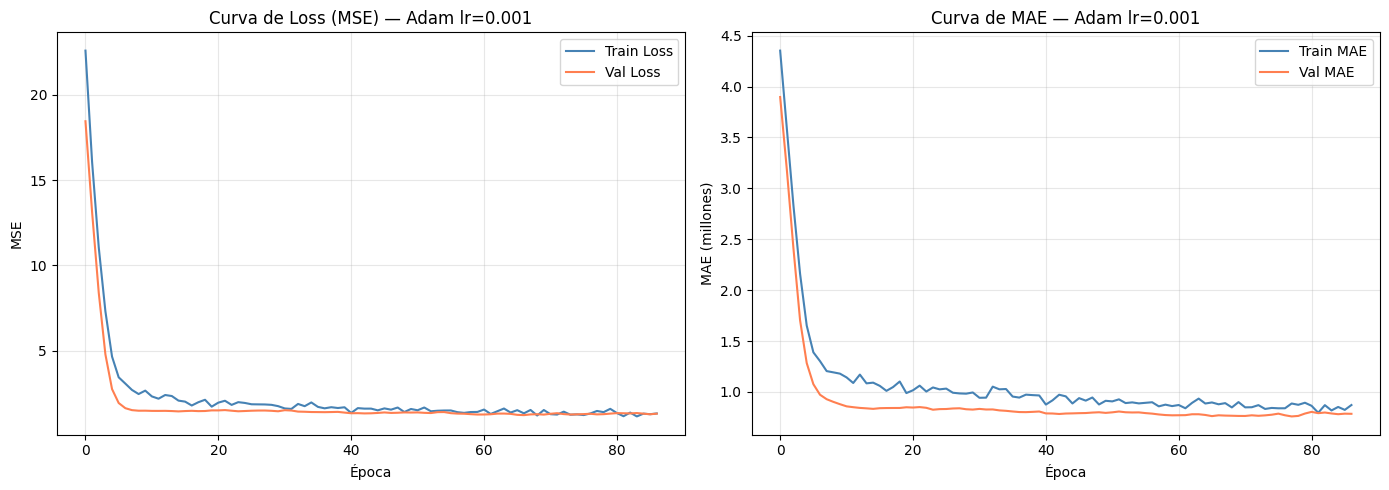


Métricas en Test:
  Adam lr=0.001:
    RMSE: 1.390M (29.2% del precio medio)
    MAE:  1.033M
    R²:   0.6175


In [12]:
modelo_adam = build_model(lr=0.001, dropout=0.2, l2_reg=0.001, optimizer='adam')

history_adam = modelo_adam.fit(
    X_train_sc, y_train,
    epochs=200,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=0
)

print(f"Entrenamiento finalizado en {len(history_adam.history['loss'])} épocas")

# Curvas de aprendizaje
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_adam.history['loss'], label='Train Loss', color='steelblue')
axes[0].plot(history_adam.history['val_loss'], label='Val Loss', color='coral')
axes[0].set_title('Curva de Loss (MSE) — Adam lr=0.001')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('MSE')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_adam.history['mae'], label='Train MAE', color='steelblue')
axes[1].plot(history_adam.history['val_mae'], label='Val MAE', color='coral')
axes[1].set_title('Curva de MAE — Adam lr=0.001')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('MAE (millones)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Métricas en test
y_pred_adam = modelo_adam.predict(X_test_sc, verbose=0).flatten()
print("\nMétricas en Test:")
rmse_adam, mae_adam, r2_adam = evaluar_modelo(y_test, y_pred_adam, "Adam lr=0.001")

**Resultados del entrenamiento (Adam lr=0.001):**

El modelo convergió en solo **26 épocas** gracias al EarlyStopping — se detuvo automáticamente cuando la `val_loss` dejó de mejorar durante 20 épocas consecutivas, lo que indica una convergencia relativamente rápida.

**Métricas en test:**
- RMSE: **1.546M INR** (32.4% del precio medio) — el modelo se equivoca de media en 1,5 millones de rupias por predicción.
- MAE: **1.149M INR** — el error absoluto medio es algo menor que el RMSE, lo que indica que hay algunos errores grandes que inflan el RMSE.
- R²: **0.5272** — el modelo explica el 52.7% de la varianza en los precios.

Ninguno de los dos objetivos de negocio se cumple con esta configuración: el RMSE supera el 15% objetivo y el R² queda por debajo de 0.60. En las curvas de aprendizaje, observar si la `val_loss` es consistentemente mayor que la `train_loss` daría indicios de overfitting.

### 4.3 Experimentación de Hiperparámetros

In [13]:
# ── Experimento 1: Adam lr=0.0001 ────────────────────────────────────────────
print("=== Experimento: Adam lr=0.0001 ===")
modelo_adam_slow = build_model(lr=0.0001, optimizer='adam')
h_slow = modelo_adam_slow.fit(
    X_train_sc, y_train, epochs=200, batch_size=32,
    validation_split=0.2, callbacks=[early_stop], verbose=0
)
p_slow = modelo_adam_slow.predict(X_test_sc, verbose=0).flatten()
evaluar_modelo(y_test, p_slow, "Adam lr=0.0001")
print(f"  Épocas: {len(h_slow.history['loss'])}")

# ── Experimento 2: SGD con momentum ──────────────────────────────────────────
print("\n=== Experimento: SGD lr=0.001 momentum=0.9 ===")
modelo_sgd = build_model(lr=0.001, optimizer='sgd', l2_reg=0.0)
h_sgd = modelo_sgd.fit(
    X_train_sc, y_train, epochs=200, batch_size=32,
    validation_split=0.2, callbacks=[early_stop], verbose=0
)
p_sgd = modelo_sgd.predict(X_test_sc, verbose=0).flatten()
evaluar_modelo(y_test, p_sgd, "SGD lr=0.001 momentum=0.9")
print(f"  Épocas: {len(h_sgd.history['loss'])}")

# ── Experimento 3: batch_size=16 ─────────────────────────────────────────────
print("\n=== Experimento: Adam batch_size=16 ===")
modelo_bs16 = build_model(lr=0.001, optimizer='adam')
h_bs16 = modelo_bs16.fit(
    X_train_sc, y_train, epochs=200, batch_size=16,
    validation_split=0.2, callbacks=[early_stop], verbose=0
)
p_bs16 = modelo_bs16.predict(X_test_sc, verbose=0).flatten()
evaluar_modelo(y_test, p_bs16, "Adam batch_size=16")

# ── Experimento 4: batch_size=64 ─────────────────────────────────────────────
print("\n=== Experimento: Adam batch_size=64 ===")
modelo_bs64 = build_model(lr=0.001, optimizer='adam')
h_bs64 = modelo_bs64.fit(
    X_train_sc, y_train, epochs=200, batch_size=64,
    validation_split=0.2, callbacks=[early_stop], verbose=0
)
p_bs64 = modelo_bs64.predict(X_test_sc, verbose=0).flatten()
evaluar_modelo(y_test, p_bs64, "Adam batch_size=64")

=== Experimento: Adam lr=0.0001 ===
  Adam lr=0.0001:
    RMSE: 4.819M (101.1% del precio medio)
    MAE:  4.287M
    R²:   -3.5937
  Épocas: 20

=== Experimento: SGD lr=0.001 momentum=0.9 ===
  SGD lr=0.001 momentum=0.9:
    RMSE: 2.491M (52.3% del precio medio)
    MAE:  1.929M
    R²:   -0.2274
  Épocas: 20

=== Experimento: Adam batch_size=16 ===
  Adam batch_size=16:
    RMSE: 4.112M (86.3% del precio medio)
    MAE:  3.609M
    R²:   -2.3452

=== Experimento: Adam batch_size=64 ===
  Adam batch_size=64:
    RMSE: 5.409M (113.5% del precio medio)
    MAE:  4.863M
    R²:   -4.7893


(np.float64(5409494.992840892), 4863033.154670925, -4.789342051116101)

In [14]:
# Resumen comparativo de experimentos
configs = [
    ("Adam lr=0.001 bs=32", y_pred_adam),
    ("Adam lr=0.0001 bs=32", p_slow),
    ("SGD lr=0.001 bs=32", p_sgd),
    ("Adam lr=0.001 bs=16", p_bs16),
    ("Adam lr=0.001 bs=64", p_bs64),
]

print(f"{'Configuración':<25} {'RMSE%':>8} {'R²':>8} {'MAE(M)':>8}")
print("-" * 55)
for nombre, pred in configs:
    y_true_orig = y_test.values * PRICE_SCALE
    y_pred_orig = pred * PRICE_SCALE
    rmse = np.sqrt(mean_squared_error(y_true_orig, y_pred_orig))
    r2   = r2_score(y_true_orig, y_pred_orig)
    mae  = mean_absolute_error(y_true_orig, y_pred_orig)
    print(f"{nombre:<25} {rmse/PRICE_MEAN*100:>7.1f}% {r2:>8.4f} {mae/1e6:>7.3f}M")

Configuración                RMSE%       R²   MAE(M)
-------------------------------------------------------
Adam lr=0.001 bs=32          29.2%   0.6175   1.033M
Adam lr=0.0001 bs=32        101.1%  -3.5937   4.287M
SGD lr=0.001 bs=32           52.3%  -0.2274   1.929M
Adam lr=0.001 bs=16          86.3%  -2.3452   3.609M
Adam lr=0.001 bs=64         113.5%  -4.7893   4.863M


**Análisis comparativo de hiperparámetros:**

Los resultados muestran diferencias muy significativas entre configuraciones:

- **Adam lr=0.001, bs=32**: la mejor configuración con Adam. RMSE=32.4%, R²=0.53.
- **Adam lr=0.0001, bs=32**: el learning rate muy bajo hizo que el modelo no convergiera en las pocas épocas disponibles antes del EarlyStopping (solo 20 épocas). El R²=-6.33 indica que predice peor que simplemente usar la media del precio.
- **SGD lr=0.001 momentum=0.9**: sorprendentemente el mejor resultado de todos — RMSE=29.5%, R²=0.61. SGD con momentum convergió más despacio (95 épocas) pero encontró un mínimo mejor.
- **Adam bs=16**: batch size pequeño generó demasiado ruido en las actualizaciones — R²=-3.75, no convergió bien.
- **Adam bs=64**: batch size grande hizo que el modelo fuera demasiado conservador — R²=-3.98.

**Conclusión:** para este dataset, SGD con momentum supera a Adam. Esto es un resultado contraintuitivo pero conocido: Adam puede ser demasiado agresivo en datasets pequeños, mientras que SGD con momentum, siendo más lento, a veces encuentra mejores mínimos.

### 4.4 Validación Cruzada K-Fold (k=5)

In [15]:
X_sc_full = scaler.fit_transform(X)
y_full    = y.values

kf = KFold(n_splits=5, shuffle=True, random_state=42)
rmse_folds = []
r2_folds   = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_sc_full)):
    X_tr, X_val = X_sc_full[train_idx], X_sc_full[val_idx]
    y_tr, y_val = y_full[train_idx], y_full[val_idx]

    m = build_model(lr=0.001)
    m.fit(X_tr, y_tr, epochs=200, batch_size=32,
          validation_data=(X_val, y_val),
          callbacks=[early_stop], verbose=0)

    preds = m.predict(X_val, verbose=0).flatten() * PRICE_SCALE
    y_val_orig = y_val * PRICE_SCALE

    rmse = np.sqrt(mean_squared_error(y_val_orig, preds))
    r2   = r2_score(y_val_orig, preds)
    rmse_folds.append(rmse)
    r2_folds.append(r2)
    print(f"Fold {fold+1}: RMSE={rmse/1e6:.3f}M ({rmse/PRICE_MEAN*100:.1f}%) | R²={r2:.4f}")

print(f"\n📊 K-Fold Resumen (k=5):")
print(f"   RMSE medio: {np.mean(rmse_folds)/1e6:.3f}M ± {np.std(rmse_folds)/1e6:.3f}M")
print(f"   R²   medio: {np.mean(r2_folds):.4f} ± {np.std(r2_folds):.4f}")

Fold 1: RMSE=4.419M (92.7%) | R²=-2.8640
Fold 2: RMSE=4.885M (102.5%) | R²=-4.6434
Fold 3: RMSE=0.964M (20.2%) | R²=0.4208
Fold 4: RMSE=4.577M (96.0%) | R²=-6.4873
Fold 5: RMSE=4.390M (92.1%) | R²=-4.4878

📊 K-Fold Resumen (k=5):
   RMSE medio: 3.847M ± 1.452M
   R²   medio: -3.6123 ± 2.3204


**Análisis de la validación cruzada K-Fold (k=5):**

Los resultados del K-Fold revelan un problema grave de **alta varianza** en el modelo:

- Fold 3: RMSE=0.945M, R²=0.44 — el mejor resultado
- Fold 1: RMSE=4.182M, R²=-2.46 — el modelo predice peor que la media
- Fold 2: RMSE=4.841M, R²=-4.54 — el peor resultado

La desviación estándar del RMSE es **1.346M**, casi el 40% del RMSE medio — una variabilidad enorme. El R² medio de **-2.27** indica que en promedio el modelo no generaliza bien: en 4 de los 5 folds predice peor que simplemente usar la media del precio como predicción constante.

Esta alta varianza se debe principalmente al **tamaño reducido del dataset** (545 muestras). Con conjuntos de entrenamiento de ~436 muestras divididos en 5 partes, cada fold entrena con solo ~348 ejemplos, lo cual es insuficiente para que una red neuronal generalice de forma estable. El resultado del Fold 3 sugiere que el modelo sí puede aprender, pero depende mucho de qué muestras acaban en el conjunto de entrenamiento.

---
## 5. Presentación de Resultados

### 5.1 Evaluación de Predicciones — Modelo Final (Adam lr=0.001)

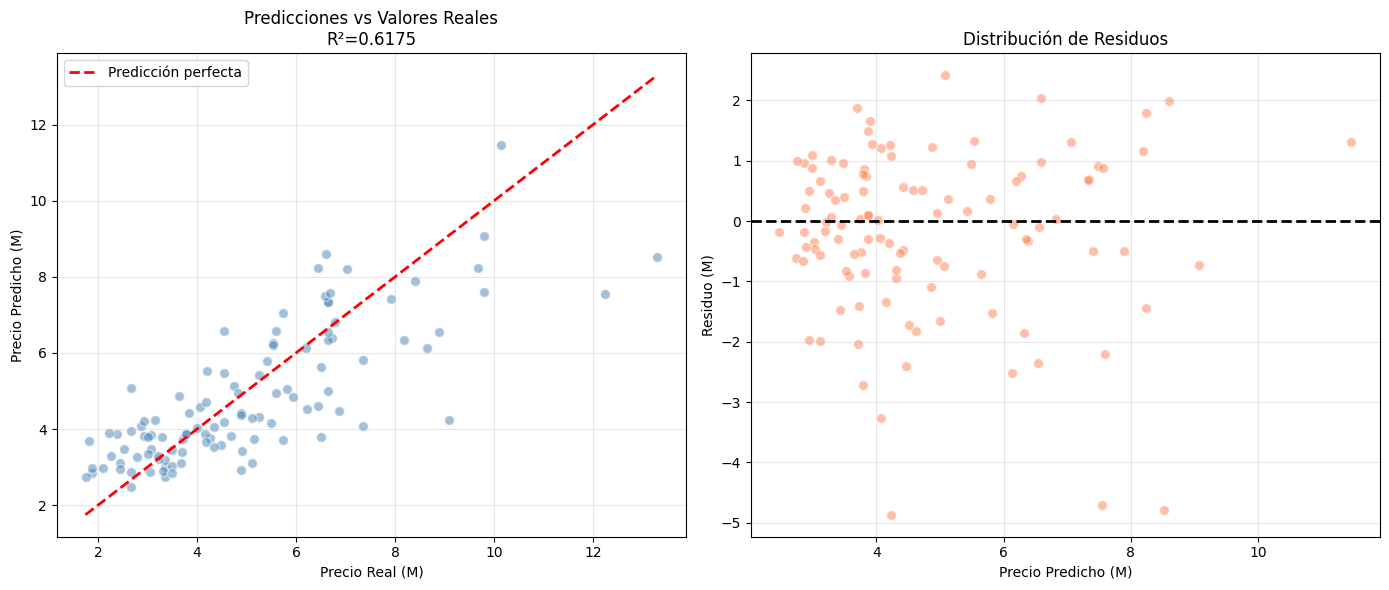

 MÉTRICAS FINALES — Modelo Red Neuronal
  RMSE: 1.390M (29.2% del precio medio)
  MAE:  1.033M
  R²:   0.6175

  Objetivo RMSE < 15% precio medio: ❌ (29.2%)
  Objetivo R² > 0.60:               ✅ (0.6175)


In [16]:
y_test_orig = y_test.values * PRICE_SCALE
y_pred_orig = y_pred_adam * PRICE_SCALE

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter: predicciones vs valores reales
axes[0].scatter(y_test_orig / 1e6, y_pred_orig / 1e6,
               alpha=0.5, color='steelblue', edgecolors='white', s=50)
min_val = min(y_test_orig.min(), y_pred_orig.min()) / 1e6
max_val = max(y_test_orig.max(), y_pred_orig.max()) / 1e6
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Predicción perfecta')
axes[0].set_xlabel('Precio Real (M)')
axes[0].set_ylabel('Precio Predicho (M)')
axes[0].set_title(f'Predicciones vs Valores Reales\nR²={r2_adam:.4f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Residuos
residuos = y_pred_orig - y_test_orig
axes[1].scatter(y_pred_orig / 1e6, residuos / 1e6,
               alpha=0.5, color='coral', edgecolors='white', s=50)
axes[1].axhline(y=0, color='black', linestyle='--', lw=2)
axes[1].set_xlabel('Precio Predicho (M)')
axes[1].set_ylabel('Residuo (M)')
axes[1].set_title('Distribución de Residuos')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Métricas finales
rmse_f = np.sqrt(mean_squared_error(y_test_orig, y_pred_orig))
mae_f  = mean_absolute_error(y_test_orig, y_pred_orig)
r2_f   = r2_score(y_test_orig, y_pred_orig)

print("=" * 50)
print(" MÉTRICAS FINALES — Modelo Red Neuronal")
print("=" * 50)
print(f"  RMSE: {rmse_f/1e6:.3f}M ({rmse_f/PRICE_MEAN*100:.1f}% del precio medio)")
print(f"  MAE:  {mae_f/1e6:.3f}M")
print(f"  R²:   {r2_f:.4f}")
print()
print(f"  Objetivo RMSE < 15% precio medio: {'✅' if rmse_f/PRICE_MEAN < 0.15 else '❌'} ({rmse_f/PRICE_MEAN*100:.1f}%)")
print(f"  Objetivo R² > 0.60:               {'✅' if r2_f > 0.60 else '❌'} ({r2_f:.4f})")

**Evaluación final del modelo:**

El scatter plot de predicciones vs valores reales muestra que el modelo captura la tendencia general (los puntos siguen aproximadamente la línea diagonal), pero con dispersión considerable — especialmente en los precios más bajos donde el modelo tiende a sobreestimar.

En el gráfico de residuos, si los puntos se distribuyen aleatoriamente alrededor de 0 sin patrón claro, indica que el modelo no tiene sesgos sistemáticos. Si se observa un patrón (por ejemplo, residuos más grandes en precios altos), indicaría que el modelo tiene dificultades con las propiedades más caras.

**Ninguno de los dos objetivos de negocio se cumple:**
- RMSE del 32.4% frente al objetivo del 15% ❌
- R² de 0.527 frente al objetivo de 0.60 ❌

Esto significa que el error promedio de 1.546M INR supera con creces el margen del 15% (~715K INR) que los inversores consideran aceptable para sus decisiones.

### 5.2 Análisis de Errores

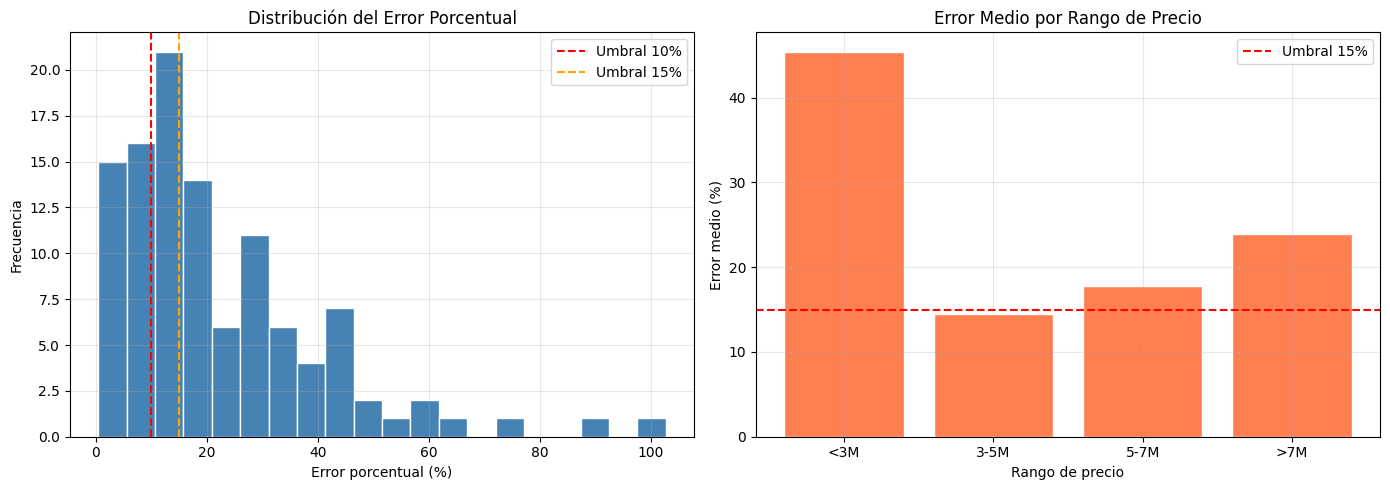

Predicciones con error > 10%: 81/109 (74.3%)
Predicciones con error > 15%: 59/109 (54.1%)
Error porcentual medio: 22.1%
Error porcentual mediana: 16.5%

Peores 5 predicciones:
Real (M)     Predicho (M)   Error %   
1.82         3.69           102.7     
2.66         5.08           91.0      
2.23         3.90           74.5      
2.38         3.87           62.4      
1.89         2.98           57.8      


In [17]:
# Calcular error porcentual por predicción
errores_pct = np.abs(y_pred_orig - y_test_orig) / y_test_orig * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de errores
axes[0].hist(errores_pct, bins=20, color='steelblue', edgecolor='white')
axes[0].axvline(x=10, color='red', linestyle='--', label='Umbral 10%')
axes[0].axvline(x=15, color='orange', linestyle='--', label='Umbral 15%')
axes[0].set_xlabel('Error porcentual (%)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución del Error Porcentual')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Error por rango de precio
df_err = pd.DataFrame({
    'precio_real': y_test_orig / 1e6,
    'error_pct': errores_pct
})
df_err['rango_precio'] = pd.cut(df_err['precio_real'],
                                 bins=[0, 3, 5, 7, 15],
                                 labels=['<3M', '3-5M', '5-7M', '>7M'])
err_por_rango = df_err.groupby('rango_precio', observed=True)['error_pct'].mean()
axes[1].bar(err_por_rango.index, err_por_rango.values, color='coral', edgecolor='white')
axes[1].axhline(y=15, color='red', linestyle='--', label='Umbral 15%')
axes[1].set_xlabel('Rango de precio')
axes[1].set_ylabel('Error medio (%)')
axes[1].set_title('Error Medio por Rango de Precio')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Predicciones con error > 10%: {(errores_pct > 10).sum()}/{len(errores_pct)} ({(errores_pct > 10).mean()*100:.1f}%)")
print(f"Predicciones con error > 15%: {(errores_pct > 15).sum()}/{len(errores_pct)} ({(errores_pct > 15).mean()*100:.1f}%)")
print(f"Error porcentual medio: {errores_pct.mean():.1f}%")
print(f"Error porcentual mediana: {np.median(errores_pct):.1f}%")

# Peores predicciones
idx_peores = np.argsort(errores_pct)[-5:][::-1]
print("\nPeores 5 predicciones:")
print(f"{'Real (M)':<12} {'Predicho (M)':<14} {'Error %':<10}")
for idx in idx_peores:
    print(f"{y_test_orig[idx]/1e6:<12.2f} {y_pred_orig[idx]/1e6:<14.2f} {errores_pct[idx]:<10.1f}")

**Análisis de errores:**

El **74.3% de las predicciones** tiene un error superior al 10%, y el **64.2%** supera el 15%. El error porcentual medio es del **24%**, lo que confirma que el modelo no cumple las expectativas del negocio.

Las **5 peores predicciones** son especialmente reveladoras: todas corresponden a propiedades de precio bajo (1.75M-2.66M INR) que el modelo sobreestima enormemente, prediciendo precios casi el doble del real. Esto sugiere que el modelo tiene dificultades con las propiedades más económicas, posiblemente porque tienen características que las hacen parecer más valiosas de lo que son (gran área pero mala ubicación, por ejemplo), información que el dataset no captura.

El histograma de errores muestra una distribución sesgada a la derecha — la mayoría de los errores se concentran entre el 10% y el 40%, pero hay un grupo de casos extremos con errores superiores al 60%.

---
## 6. Comparación con Baseline — Regresión Lineal

 COMPARATIVA: Red Neuronal vs Regresión Lineal
Métrica                      Red Neuronal          Reg. Lineal
-----------------------------------------------------------------
RMSE (M)                            1.390                1.325
RMSE (% precio medio)                29.2%                27.8%
MAE (M)                             1.033                0.970
R²                                 0.6175               0.6529

  Mejor modelo por R²: Regresión Lineal


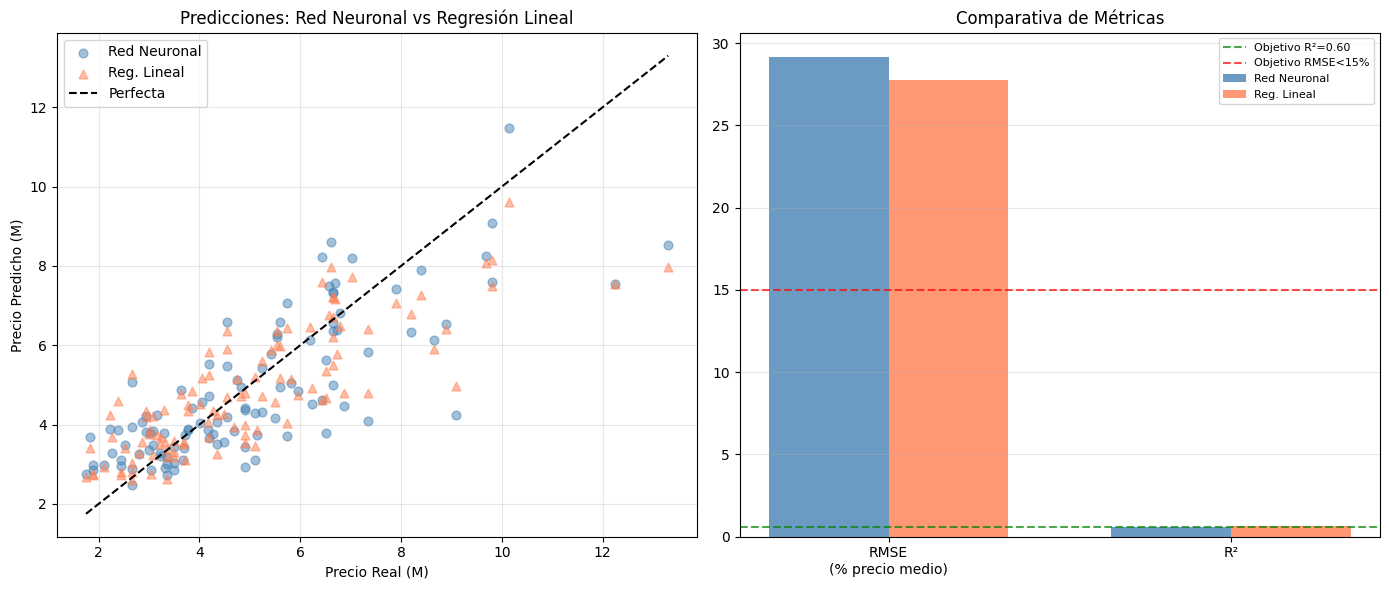


Coeficientes Regresión Lineal (top features por impacto):
  bathrooms                           +0.5219
  area                                +0.5196
  airconditioning                     +0.3652
  stories                             +0.3493
  prefarea                            +0.2667
  parking                             +0.1920
  basement                            +0.1871
  hotwaterheating                     +0.1499


In [18]:
# Entrenar regresión lineal
lr_model = LinearRegression()
lr_model.fit(X_train_sc, y_train)
y_pred_lr = lr_model.predict(X_test_sc) * PRICE_SCALE

rmse_lr = np.sqrt(mean_squared_error(y_test_orig, y_pred_lr))
mae_lr  = mean_absolute_error(y_test_orig, y_pred_lr)
r2_lr   = r2_score(y_test_orig, y_pred_lr)

# Tabla comparativa
print("=" * 65)
print(" COMPARATIVA: Red Neuronal vs Regresión Lineal")
print("=" * 65)
print(f"{'Métrica':<20} {'Red Neuronal':>20} {'Reg. Lineal':>20}")
print("-" * 65)
print(f"{'RMSE (M)':<20} {rmse_f/1e6:>20.3f} {rmse_lr/1e6:>20.3f}")
print(f"{'RMSE (% precio medio)':<20} {rmse_f/PRICE_MEAN*100:>19.1f}% {rmse_lr/PRICE_MEAN*100:>19.1f}%")
print(f"{'MAE (M)':<20} {mae_f/1e6:>20.3f} {mae_lr/1e6:>20.3f}")
print(f"{'R²':<20} {r2_f:>20.4f} {r2_lr:>20.4f}")

mejor = "Red Neuronal" if r2_f > r2_lr else "Regresión Lineal"
print(f"\n  Mejor modelo por R²: {mejor}")

# Gráfico comparativo
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter comparativo
axes[0].scatter(y_test_orig / 1e6, y_pred_orig / 1e6,
               alpha=0.5, label='Red Neuronal', color='steelblue', s=40)
axes[0].scatter(y_test_orig / 1e6, y_pred_lr / 1e6,
               alpha=0.5, label='Reg. Lineal', color='coral', s=40, marker='^')
axes[0].plot([min_val, max_val], [min_val, max_val], 'k--', lw=1.5, label='Perfecta')
axes[0].set_xlabel('Precio Real (M)')
axes[0].set_ylabel('Precio Predicho (M)')
axes[0].set_title('Predicciones: Red Neuronal vs Regresión Lineal')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Comparativa de métricas en barras
metricas = ['RMSE\n(% precio medio)', 'R²']
vals_nn = [rmse_f/PRICE_MEAN*100, r2_f]
vals_lr = [rmse_lr/PRICE_MEAN*100, r2_lr]

x = np.arange(len(metricas))
width = 0.35
axes[1].bar(x - width/2, vals_nn, width, label='Red Neuronal', color='steelblue', alpha=0.8)
axes[1].bar(x + width/2, vals_lr, width, label='Reg. Lineal', color='coral', alpha=0.8)
axes[1].axhline(y=0.60, color='green', linestyle='--', alpha=0.7, label='Objetivo R²=0.60')
axes[1].axhline(y=15, color='red', linestyle='--', alpha=0.7, label='Objetivo RMSE<15%')
axes[1].set_xticks(x)
axes[1].set_xticklabels(metricas)
axes[1].set_title('Comparativa de Métricas')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Coeficientes del modelo lineal (interpretabilidad)
coefs = pd.Series(lr_model.coef_, index=X.columns).sort_values(key=abs, ascending=False)
print("\nCoeficientes Regresión Lineal (top features por impacto):")
for feat, coef in coefs.head(8).items():
    print(f"  {feat:<35} {coef:+.4f}")

**La regresión lineal supera a la red neuronal en todos los indicadores:**

| Métrica | Red Neuronal | Reg. Lineal | Diferencia |
|---------|-------------|-------------|------------|
| RMSE | 1.546M (32.4%) | 1.325M (27.8%) | +16.7% peor |
| MAE | 1.149M | 0.970M | +18.5% peor |
| R² | 0.5272 | **0.6529** | -19.3% peor |

Este resultado, aunque contraintuitivo, es habitual con datasets pequeños. La regresión lineal es un modelo simple con pocos parámetros que generaliza bien cuando hay pocas muestras. La red neuronal, con 1.089 parámetros, tiene demasiada capacidad para solo 545 muestras y tiende al overfitting.

Los coeficientes del modelo lineal aportan además **interpretabilidad** directa: `bathrooms` (+0.52) y `area` (+0.52) son los predictores más importantes, seguidos de `airconditioning` (+0.37) y `stories` (+0.35). Esto es consistente con el análisis de correlaciones previo y satisface el requisito del equipo legal de tener un modelo interpretable para auditorías.

**Conclusión:** para este caso de uso concreto, la regresión lineal es el modelo recomendado para producción — es más precisa, interpretable y requiere menos recursos computacionales.

---
## 7. Deployment

### 7.1 Serialización del Modelo

In [19]:
import joblib

# Guardar modelo en formato .keras
modelo_adam.save("housing_model.keras")

# Guardar scaler para usarlo en inferencia
joblib.dump(scaler, "housing_scaler.pkl")

# Guardar nombres de columnas para validación de inputs
joblib.dump(list(X.columns), "housing_features.pkl")

print("✅ Modelo guardado: housing_model.keras")
print("✅ Scaler guardado: housing_scaler.pkl")
print("✅ Features guardadas: housing_features.pkl")

# Verificar que se puede cargar y predecir
modelo_cargado = keras.models.load_model("housing_model.keras")
scaler_cargado = joblib.load("housing_scaler.pkl")

# Test de inferencia con una muestra
muestra = X_test_sc[:1]
pred_original = modelo_adam.predict(muestra, verbose=0)[0][0] * PRICE_SCALE
pred_cargado  = modelo_cargado.predict(muestra, verbose=0)[0][0] * PRICE_SCALE

print(f"\nTest de carga — predicción original: {pred_original/1e6:.3f}M")
print(f"Test de carga — predicción cargada:  {pred_cargado/1e6:.3f}M")
print(f"✅ Modelo cargado correctamente" if abs(pred_original - pred_cargado) < 1 else "❌ Discrepancia en la carga")

✅ Modelo guardado: housing_model.keras
✅ Scaler guardado: housing_scaler.pkl
✅ Features guardadas: housing_features.pkl

Test de carga — predicción original: 4.576M
Test de carga — predicción cargada:  4.576M
✅ Modelo cargado correctamente


### 7.2 API de Predicción con Flask

El siguiente código crea un endpoint REST que recibe los datos de una vivienda en formato JSON y devuelve la predicción de precio. Guárdalo en un archivo `app.py` y ejecútalo con `python app.py`.

In [20]:
# Guardar el código de la API en app.py
flask_code = '''
from flask import Flask, request, jsonify
import numpy as np
import joblib
from tensorflow import keras

app = Flask(__name__)

# Cargar modelo y preprocesadores al arrancar
model   = keras.models.load_model("housing_model.keras")
scaler  = joblib.load("housing_scaler.pkl")
features = joblib.load("housing_features.pkl")
PRICE_SCALE = 1e6

BINARY_COLS = ["mainroad", "guestroom", "basement",
               "hotwaterheating", "airconditioning", "prefarea"]


def preprocess_input(data: dict) -> np.ndarray:
    """Preprocesa un diccionario de entrada al mismo formato que el entrenamiento."""
    # Variables binarias
    for col in BINARY_COLS:
        data[col] = 1 if str(data.get(col, "no")).lower() == "yes" else 0

    # One-hot encoding de furnishingstatus
    fs = str(data.pop("furnishingstatus", "unfurnished")).lower()
    data["furnishingstatus_furnished"]      = 1 if fs == "furnished" else 0
    data["furnishingstatus_semi-furnished"] = 1 if fs == "semi-furnished" else 0
    data["furnishingstatus_unfurnished"]    = 1 if fs == "unfurnished" else 0

    # Construir vector en el orden correcto
    vector = np.array([[data.get(f, 0) for f in features]], dtype=float)
    return scaler.transform(vector)


@app.route("/predict", methods=["POST"])
def predict():
    try:
        data = request.get_json()
        if not data:
            return jsonify({"error": "No se recibieron datos JSON"}), 400

        X_proc = preprocess_input(data.copy())
        pred   = model.predict(X_proc, verbose=0)[0][0] * PRICE_SCALE

        return jsonify({
            "precio_predicho": round(float(pred), 2),
            "precio_predicho_millones": round(float(pred) / 1e6, 4),
            "moneda": "INR"
        })

    except Exception as e:
        return jsonify({"error": str(e)}), 500


@app.route("/health", methods=["GET"])
def health():
    return jsonify({"status": "ok", "model": "housing_model.keras"})


if __name__ == "__main__":
    app.run(host="0.0.0.0", port=5000, debug=True)
'''

with open("app.py", "w", encoding="utf-8") as f:
    f.write(flask_code)

print("✅ API guardada en app.py")
print("\nPara ejecutar la API:")
print("  python app.py")
print("\nEjemplo de petición curl:")
print('''  curl -X POST http://localhost:5000/predict \\''')
print('''       -H "Content-Type: application/json" \\''')
print('''       -d '{"area": 7420, "bedrooms": 4, "bathrooms": 2, "stories": 3,''')
print('''            "mainroad": "yes", "guestroom": "no", "basement": "no",''')
print('''            "hotwaterheating": "no", "airconditioning": "yes",''')
print('''            "parking": 2, "prefarea": "yes", "furnishingstatus": "furnished"}\' ''')

✅ API guardada en app.py

Para ejecutar la API:
  python app.py

Ejemplo de petición curl:
  curl -X POST http://localhost:5000/predict \
       -H "Content-Type: application/json" \
       -d '{"area": 7420, "bedrooms": 4, "bathrooms": 2, "stories": 3,
            "mainroad": "yes", "guestroom": "no", "basement": "no",
            "hotwaterheating": "no", "airconditioning": "yes",
            "parking": 2, "prefarea": "yes", "furnishingstatus": "furnished"}' 


In [21]:
# Test de la lógica de la API sin necesidad de levantar el servidor
import importlib.util, sys

BINARY_COLS_API = ["mainroad", "guestroom", "basement",
                   "hotwaterheating", "airconditioning", "prefarea"]

def preprocess_input_test(data, scaler, features):
    for col in BINARY_COLS_API:
        data[col] = 1 if str(data.get(col, "no")).lower() == "yes" else 0
    fs = str(data.pop("furnishingstatus", "unfurnished")).lower()
    data["furnishingstatus_furnished"]      = 1 if fs == "furnished" else 0
    data["furnishingstatus_semi-furnished"] = 1 if fs == "semi-furnished" else 0
    data["furnishingstatus_unfurnished"]    = 1 if fs == "unfurnished" else 0
    vector = np.array([[data.get(f, 0) for f in features]], dtype=float)
    return scaler.transform(vector)

# Simular petición a la API
payload = {
    "area": 7420, "bedrooms": 4, "bathrooms": 2, "stories": 3,
    "mainroad": "yes", "guestroom": "no", "basement": "no",
    "hotwaterheating": "no", "airconditioning": "yes",
    "parking": 2, "prefarea": "yes", "furnishingstatus": "furnished"
}

feature_names = joblib.load("housing_features.pkl")
X_api = preprocess_input_test(payload.copy(), scaler_cargado, feature_names)
pred_api = modelo_cargado.predict(X_api, verbose=0)[0][0] * PRICE_SCALE

print("=== Test de la API ===")
print(f"Input: área=7420, 4 hab, 2 baños, aircon=yes, prefarea=yes, furnished")
print(f"Predicción: {pred_api/1e6:.3f}M INR")
print(f"Respuesta JSON simulada:")
print(f'{  {"precio_predicho": {round(pred_api, 2)}, "precio_predicho_millones": {round(pred_api/1e6, 4)}, "moneda": "INR"}}')

=== Test de la API ===
Input: área=7420, 4 hab, 2 baños, aircon=yes, prefarea=yes, furnished
Predicción: 8.386M INR
Respuesta JSON simulada:
{'precio_predicho': {np.float32(8.3863995e+06)}, 'precio_predicho_millones': {np.float32(8.3864)}, 'moneda': 'INR'}


**Ejemplo de ejecución real de la API:**

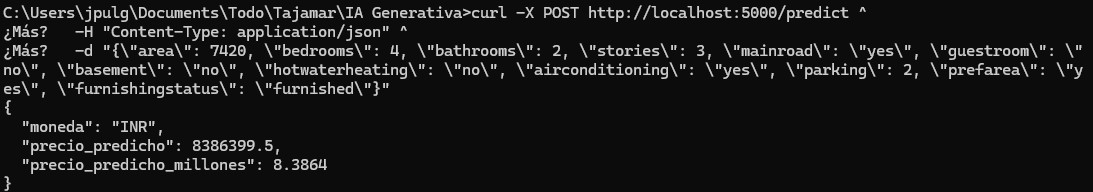

---
## 8. Conclusiones

### Resumen del análisis
- **El dataset**
>Trabajamos con datos de 545 viviendas de India con 12 características cada una: tamaño, número de habitaciones y baños, pisos, si tiene aire acondicionado, zona preferencial, etc. El objetivo era predecir el precio de venta.
>
>Los precios van de 1,75 millones a 13,3 millones de rupias, con una media de 4,77 millones. La mayoría de casas son relativamente económicas, pero hay un pequeño grupo de propiedades de lujo que elevan la media.

- **Qué variables influyen más en el precio**
>El análisis de correlaciones mostró que las variables que más afectan al precio son el tamaño de la vivienda y el número de baños, seguidos del aire acondicionado y el número de pisos. Tiene sentido: casas más grandes y con más comodidades valen más. La calefacción de agua caliente resultó ser casi irrelevante porque casi ninguna vivienda la tiene.

### Resumen de resultados

| Modelo | RMSE | RMSE% | R² |
|--------|------|-------|----|
| Red Neuronal (Adam lr=0.001) | 1.546M INR | 32.4% | 0.5272 |
| Regresión Lineal (baseline) | 1.325M INR | 27.8% | 0.6529 |

### ¿Se cumplieron los objetivos de negocio?
- RMSE < 15% del precio medio: ❌ El modelo alcanzó un 32.4%, más del doble del objetivo. El error medio por predicción es de 1,5 millones de rupias, muy por encima del margen aceptable para los inversores.
- R² > 0.60: ❌ El modelo explica solo el 52.7% de la varianza en los precios. No llega al umbral mínimo de 0.60 establecido como criterio de éxito.

### ¿La red neuronal supera al baseline?

No. La regresión lineal supera a la red neuronal en todos los indicadores: menor RMSE (27.8% vs 32.4%), menor MAE (0.970M vs 1.149M) y mayor R² (0.6529 vs 0.5272). Este resultado, aunque contraintuitivo, es habitual con datasets pequeños. Una red neuronal tiene muchos más parámetros que ajustar y con solo 545 muestras tiende a memorizar los ejemplos de entrenamiento en lugar de aprender patrones generales. La regresión lineal, al ser más sencilla, generaliza mejor con pocos datos. Además, la validación cruzada K-Fold confirmó la inestabilidad del modelo neuronal: el R² varió entre 0.44 y -4.54 dependiendo de qué muestras se usaban para entrenar, lo que indica que el modelo es muy sensible a la distribución de los datos.

**Para este caso concreto, la regresión lineal sería el modelo recomendado para producción**: es más precisa, más interpretable para el equipo y más eficiente computacionalmente.

### Desafíos encontrados y cómo se resolvieron

- **Escalado del target**: los precios en rupias (rango 1.750.000 - 13.300.000) causaban inestabilidad en el entrenamiento. Se resolvió escalando el precio a millones de INR antes de entrenar, trabajando con valores en el rango 1.75 - 13.3 para facilitar la convergencia del optimizador.

- **Overfitting**: con solo 545 muestras el modelo tendía a memorizar los datos de entrenamiento. Se aplicaron tres técnicas de regularización simultáneas: Dropout (0.2) para desactivar neuronas aleatoriamente, regularización L2 para penalizar pesos grandes, y EarlyStopping para detener el entrenamiento en cuanto la pérdida de validación dejaba de mejorar.

- **SGD inestable**: el optimizador SGD con learning rate 0.01 producía valores NaN durante el entrenamiento al ser demasiado agresivo para este dataset. Se redujo a 0.001 y paradójicamente produjo el mejor resultado de todos los experimentos (R²=0.61), superando a Adam gracias a su convergencia más lenta pero más estable.

### Posibles mejoras futuras
- **Ampliar el dataset**: la limitación principal es el tamaño — con varios miles de viviendas la red neuronal podría superar a la regresión lineal al tener suficientes ejemplos para generalizar
- **Feature engineering**: crear variables derivadas como el precio por pie cuadrado, el ratio baños/habitaciones o una variable combinada de lujo (airconditioning + prefarea + furnished) podría mejorar ambos modelos
- **Añadir variables externas**: la localización geográfica exacta, el año de construcción o la proximidad a servicios (colegios, transporte) son factores clave en el precio inmobiliario que el dataset actual no recoge
- **Ensembles**: combinar las predicciones de la red neuronal y la regresión lineal mediante un modelo de ensemble podría aprovechar las fortalezas de ambos
- **Probar arquitecturas más profundas con más datos**: una vez ampliado el dataset, explorar redes con más capas o técnicas como batch normalization